<a href="https://colab.research.google.com/github/leo-aguiar/california_housing_ml/blob/main/california_housing_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Sobre o conjunto de dados**

**Contexto**

Este é o conjunto de dados usado no segundo capítulo do livro recente de Aurélien Géron, "Hands-On Machine Learning with Scikit-Learn and TensorFlow".

**Conteúdo**

Os dados referem-se às casas encontradas em um determinado distrito da Califórnia e a algumas estatísticas resumidas sobre elas, com base nos dados do censo de 1990. As colunas são as seguintes, e seus nomes são bastante autoexplicativos:

* id

* latitude

* longitude

* median_age

* total_rooms

* total_bedrooms

* population

* households

* median_income

* median_house_value

### **Objetivo**

Prever o valor mediano das casas em um distrito da Califórnia usando dados demográficos e geográficos.


### **Entendimento dos Dados**

Objetivo: saber o que cada variável representa.

Colunas importantes:

* id - id único de cada local

* latitude - latitude do local

* longitude - longitude do local

* median_age - mediana das idades das casas no local

* total_rooms - contagem do total de cômodos na região

* total_bedrooms - contagem do total de quartos na região

* population - população total na região

* households - número total de casas na região

* median_income - mediana da renda das pessoas na região (em dezenas de milhares por ano)

* median_house_value - mediana dos valores das casas da região - **variável-alvo**

-> Este conjunto de dados contém uma linha por grupo de blocos do censo. Um grupo de quarteirões é a menor unidade geográfica para a qual o U.S. Census Bureau publica dados de amostra (um grupo de quarteirões normalmente tem uma população de 600 a 3000 pessoas).

### **Análise Exploratória de Dados (EDA)**

In [1]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carregar arquivo
df = pd.read_csv('./sample_data/california_housing_train.csv')

In [3]:
# Visualizar as primeiras linhas
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [4]:
# Informações sobre os tipos de colunas e dados faltantes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [5]:
# Resumo Estatístico
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
# Verificar dimensões (linhas, colunas)
print(f'Linhas: {df.shape[0]}\nColunas: {df.shape[1]}')

Linhas: 17000
Colunas: 9


In [7]:
# Verificar valores faltantes (missing values)
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


In [8]:
# Verificar dados duplicados
df.duplicated().sum()

np.int64(0)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

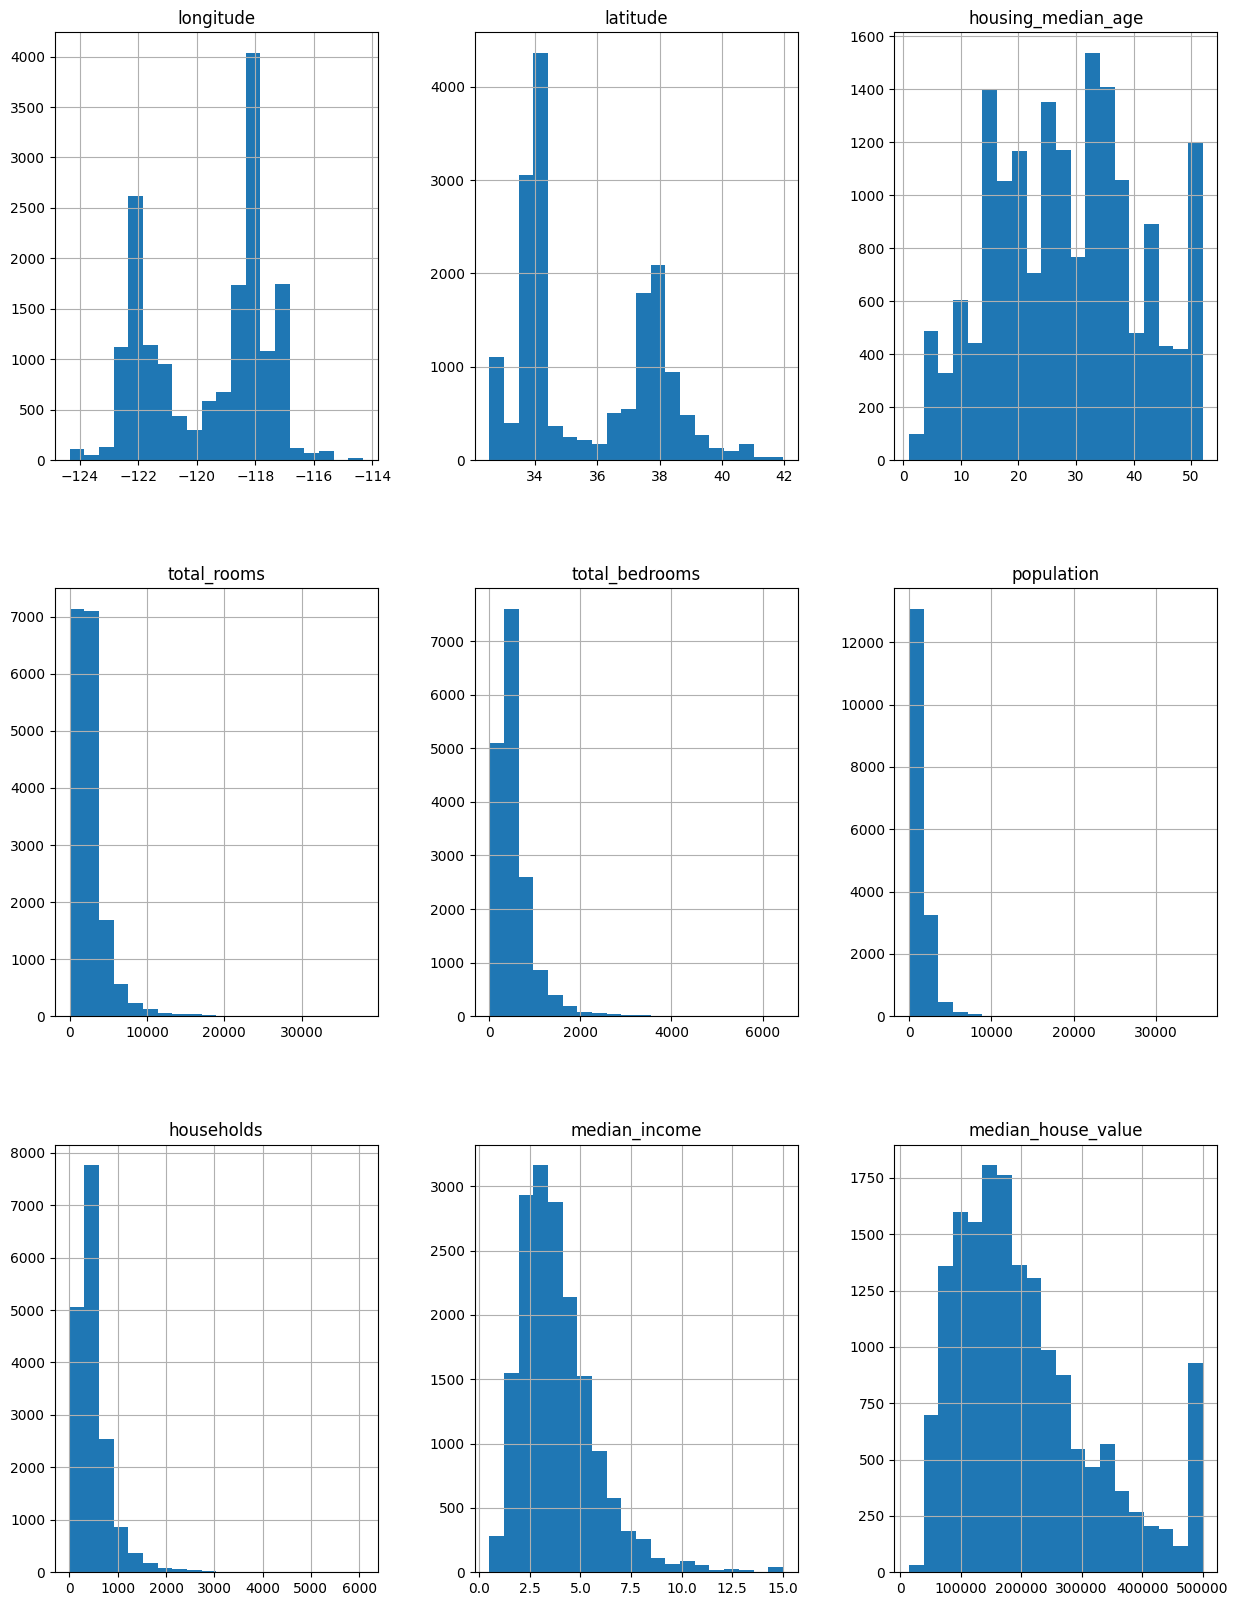

In [9]:
# Histograma de variáveis numéricas
df.hist(bins=20, figsize=(15, 20))

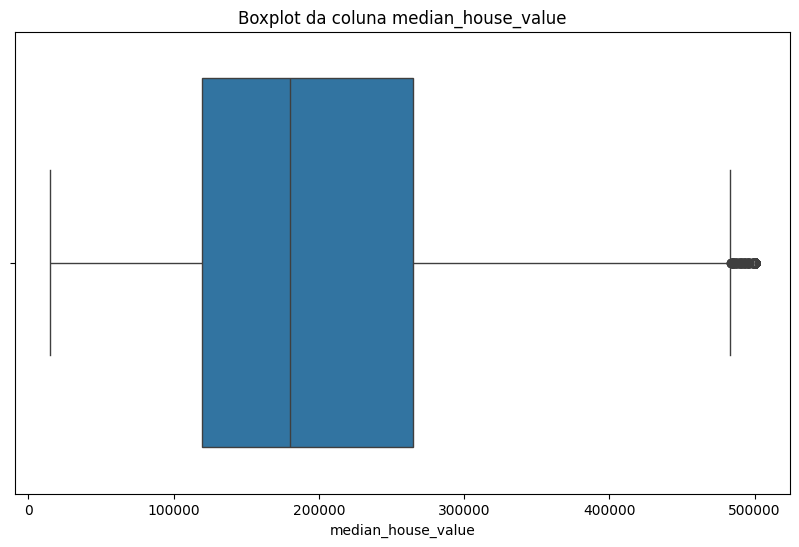

In [10]:
# Boxplot para detectar outliers
plt.figure(figsize=(10,6))
sns.boxplot(x=df['median_house_value'])
plt.title('Boxplot da coluna median_house_value')
plt.show()

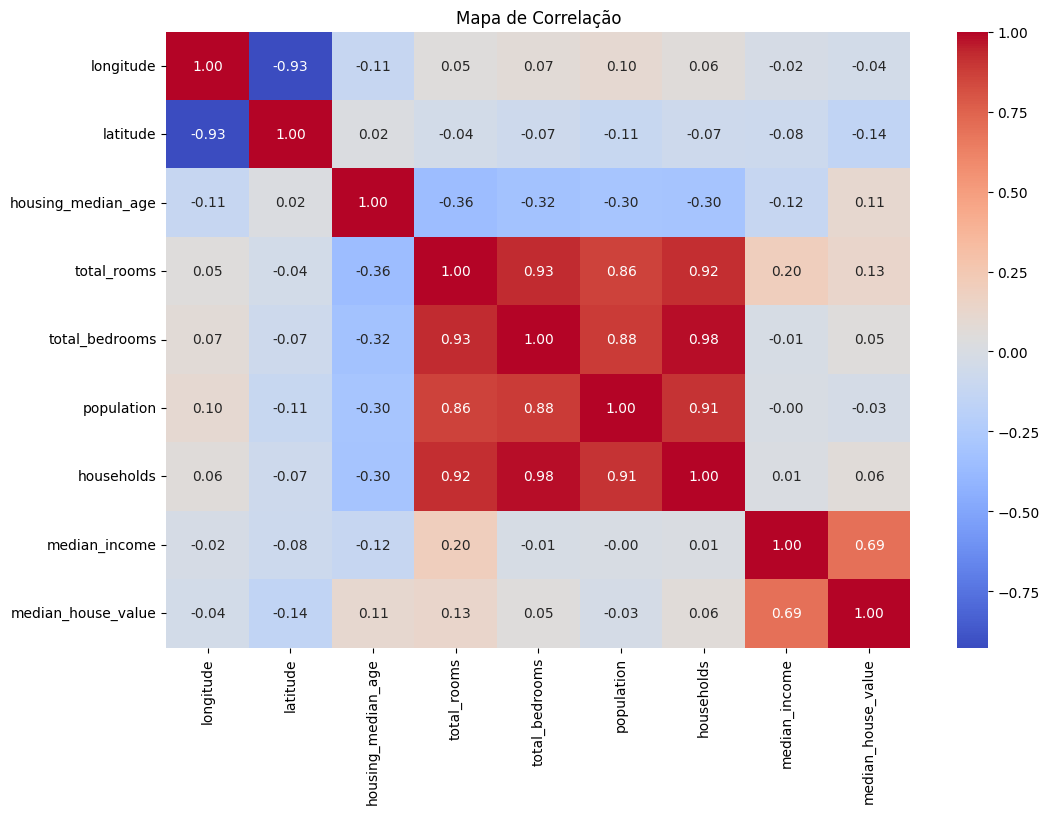

In [11]:
# Mapa de calor de correlação (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlação')
plt.show()

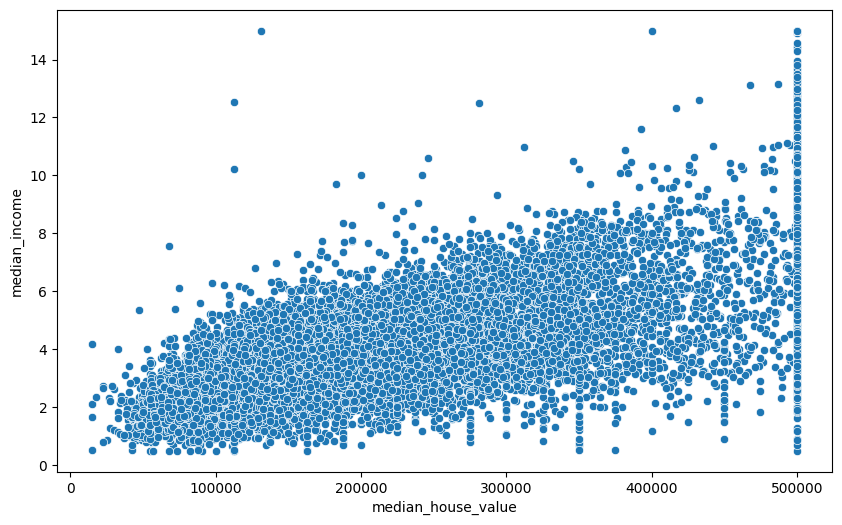

In [12]:
# Scatterplot (Dispersão) - Relação entre duas variáveis numéricas
plt.figure(figsize=(10, 6))
sns.scatterplot(x='median_house_value', y='median_income', data=df)
plt.show()

In [ ]:
!pip install ydata_profiling

In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, explorative=True)
profile

### **Processo de Machine Learning**

Obs:. Como esse dataset é pré-pronto (utilizado em muitos exemplos de livros, sites, etc) não há muito o que pré-processar dos dados.


-> Determinação do alvo (preço médio das casas)

In [13]:
y = df['median_house_value']

In [14]:
y

,median_house_value
0,66900.0
1,80100.0
2,85700.0
3,73400.0
4,65500.0
...,...
16995,111400.0
16996,79000.0
16997,103600.0
16998,85800.0


-> Escolha das features (variáveis a serem utilizadas do conjunto de dados)

In [15]:
features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

In [16]:
X = df[features]

In [17]:
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250
...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797


-> Construção do Modelo



*   Biblioteca: Scikit-Learn
*   Definição: Escolha do Modelo (define Parâmetros)
*   Fit: Treino
*   Predict: Faz a Predição
*   Evaluate: Avalia os resultados



In [18]:
from sklearn.neighbors import KNeighborsRegressor

In [19]:
modelo = KNeighborsRegressor(n_neighbors=3)

-> Treinamento do Modelo

In [20]:
modelo.fit(X, y)

KNeighborsRegressor(n_neighbors=3)

-> Predição

In [21]:
modelo.predict(X.head(5))

array([121966.66666667, 176900.        , 148066.66666667, 106700.        ,
       134300.        ])

In [22]:
df.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


-> Validação do Modelo

In [23]:
from sklearn.metrics import mean_absolute_error

In [24]:
predicao = modelo.predict(X)

In [25]:
predicao

array([121966.66666667, 176900.        , 148066.66666667, ...,
       106666.66666667, 128833.33333333, 252233.66666667])

In [26]:
mean_absolute_error(y, predicao)

55582.95749019608

In [27]:
df_verificacao = pd.DataFrame(y)

In [28]:
df_verificacao['predicao'] = predicao

In [29]:
df_verificacao.sample(10)

,median_house_value,predicao
6458,268800.0,230066.666667
2407,191700.0,176933.333333
15507,237500.0,313433.333333
13045,147000.0,167900.000000
14300,500001.0,454834.000000
2622,250800.0,217766.666667
11297,115200.0,161466.666667
9319,267300.0,230466.666667
3926,158600.0,155833.333333
16273,332700.0,280433.333333


In [30]:
df_verificacao.describe()

,median_house_value,predicao
count,17000.000000,17000.000000
mean,207300.912353,207369.360078
std,115983.764387,88609.781215
min,14999.000000,38166.333333
25%,119400.000000,143533.333333
50%,180400.000000,186300.000000
75%,265000.000000,253575.250000
max,500001.000000,500001.000000


-> Validação (outra forma)

In [31]:
from sklearn.model_selection import train_test_split

* Utilizar 80% dos dados para treinar e 20% para testar

In [32]:
treino_X, val_X, treino_y, val_y = train_test_split(X, y, random_state=1, train_size=0.8, test_size=0.2)

In [33]:
treino_X.shape

(13600, 8)

In [34]:
modelo_2 = KNeighborsRegressor(n_neighbors=3)

In [35]:
modelo_2.fit(treino_X, treino_y)

KNeighborsRegressor(n_neighbors=3)

In [36]:
predicao_2 = modelo_2.predict(val_X)

In [37]:
mean_absolute_error(val_y, predicao_2)

81475.73088235295

-> Utilizando algoritmo de  Árvores de Decisão

In [38]:
from sklearn.tree import DecisionTreeRegressor

In [39]:
#modelo_tree = DecisionTreeRegressor(random_state=1, max_depth=8)
modelo_tree = DecisionTreeRegressor(random_state=1, min_samples_leaf=15)

In [40]:
modelo_tree.fit(X, y)

DecisionTreeRegressor(min_samples_leaf=15, random_state=1)

In [41]:
predicao_tree = modelo_tree.predict(X)

In [42]:
mean_absolute_error(y, predicao_tree)

30824.120657959214

-> Separando dados em treino e teste

In [43]:
modelo_tree.fit(treino_X, treino_y)

DecisionTreeRegressor(min_samples_leaf=15, random_state=1)

In [44]:
predicao = modelo_tree.predict(val_X)

In [45]:
mean_absolute_error(val_y, predicao)

39663.62098113428

-> Utilizando o algoritmo Random Forest

In [48]:
from sklearn.ensemble import RandomForestRegressor

In [50]:
modelorf = RandomForestRegressor(random_state=1, n_jobs=-1, n_estimators=200)
# modelorf = RandomForestRegressor(random_state=1, n_job=-1, n_estimators=500)

In [51]:
modelorf.fit(treino_X, treino_y)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=1)

In [52]:
predicao = modelorf.predict(val_X)

In [53]:
mean_absolute_error(val_y, predicao)

31134.331648529413